In [1]:
!pip install kagglehub
!pip install matplotlib seaborn

In [2]:
import kagglehub
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings("ignore")

df = pd.read_csv("Netflix TV Shows and Movies.csv")   # Replace with your actual filename
df.head()

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,tt0079470,8.0,392419.0
3,3,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,tt0070047,8.1,391942.0
4,4,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,tt0063929,8.8,72895.0


# Part A – Pandas Basics

In [3]:
# Display first 10 and last 10 rows 
print("First :", df.head())
print("Last :", df.tail())

First :    index        id                            title   type  \
0      0   tm84618                      Taxi Driver  MOVIE   
1      1  tm127384  Monty Python and the Holy Grail  MOVIE   
2      2   tm70993                    Life of Brian  MOVIE   
3      3  tm190788                     The Exorcist  MOVIE   
4      4   ts22164     Monty Python's Flying Circus   SHOW   

                                         description  release_year  \
0  A mentally unstable Vietnam War veteran works ...          1976   
1  King Arthur, accompanied by his squire, recrui...          1975   
2  Brian Cohen is an average young Jewish man, bu...          1979   
3  12-year-old Regan MacNeil begins to adapt an e...          1973   
4  A British sketch comedy series with the shows ...          1969   

  age_certification  runtime    imdb_id  imdb_score  imdb_votes  
0                 R      113  tt0075314         8.3    795222.0  
1                PG       91  tt0071853         8.2    530877.0  


In [4]:
# Number of rows and columns 
print(df.shape)

(5283, 11)


In [5]:
# Number of rows 
print(df.shape[0])

5283


In [6]:
# Number of columns 
print(df.shape[1])


11


In [7]:
# Column names 
print(df.columns)

Index(['index', 'id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'imdb_id', 'imdb_score', 'imdb_votes'],
      dtype='object')


In [8]:
# Data types 
print(df.dtypes)

index                  int64
id                    object
title                 object
type                  object
description           object
release_year           int64
age_certification     object
runtime                int64
imdb_id               object
imdb_score           float64
imdb_votes           float64
dtype: object


In [9]:
# Memory usage 
df.info(memory_usage="deep") 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5283 entries, 0 to 5282
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              5283 non-null   int64  
 1   id                 5283 non-null   object 
 2   title              5283 non-null   object 
 3   type               5283 non-null   object 
 4   description        5278 non-null   object 
 5   release_year       5283 non-null   int64  
 6   age_certification  2998 non-null   object 
 7   runtime            5283 non-null   int64  
 8   imdb_id            5283 non-null   object 
 9   imdb_score         5283 non-null   float64
 10  imdb_votes         5267 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 3.3 MB


In [10]:
# Descriptive statistics 
print(df.describe())

             index  release_year      runtime   imdb_score    imdb_votes
count  5283.000000   5283.000000  5283.000000  5283.000000  5.267000e+03
mean   2641.000000   2015.879992    79.199886     6.533447  2.340719e+04
std    1525.215067      7.346098    38.915974     1.160932  8.713432e+04
min       0.000000   1953.000000     0.000000     1.500000  5.000000e+00
25%    1320.500000   2015.000000    45.000000     5.800000  5.210000e+02
50%    2641.000000   2018.000000    87.000000     6.600000  2.279000e+03
75%    3961.500000   2020.000000   106.000000     7.400000  1.014400e+04
max    5282.000000   2022.000000   235.000000     9.600000  2.268288e+06


In [11]:
# Missing values 
print(df.isnull().sum())

index                   0
id                      0
title                   0
type                    0
description             5
release_year            0
age_certification    2285
runtime                 0
imdb_id                 0
imdb_score              0
imdb_votes             16
dtype: int64


In [12]:
# Remove rows containing missing values 
df_new = df.dropna()

print(df_new) 


      index        id                            title   type  \
0         0   tm84618                      Taxi Driver  MOVIE   
1         1  tm127384  Monty Python and the Holy Grail  MOVIE   
2         2   tm70993                    Life of Brian  MOVIE   
3         3  tm190788                     The Exorcist  MOVIE   
4         4   ts22164     Monty Python's Flying Circus   SHOW   
...     ...       ...                              ...    ...   
5252   5252  ts309235                   Christmas Flow   SHOW   
5254   5254  ts307816      Korean Cold Noodle Rhapsody   SHOW   
5257   5257  tm982470                      Stuck Apart  MOVIE   
5266   5266  ts273317                    Pitta Kathalu   SHOW   
5275   5275  ts286386                      The Big Day   SHOW   

                                            description  release_year  \
0     A mentally unstable Vietnam War veteran works ...          1976   
1     King Arthur, accompanied by his squire, recrui...          1975   


In [13]:
# Fill missing values
# age_certification with "Unknown"
# imdb_score using the column mean.

df["age_certification"] = df["age_certification"].fillna("Unknown")

df["imdb_score"] = df["imdb_score"].fillna(
    df["imdb_score"].mean()
)

In [14]:
# Find duplicate rows and remove them.
print(df.duplicated().sum())

df = df.drop_duplicates()

0


In [15]:
# # Rename:
# release_year → year
# runtime → duration

df.rename(columns={
    "release_year":"year",
    "runtime":"duration"
}, inplace=True) 

df 

,index,id,title,type,description,year,age_certification,duration,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,tt0079470,8.0,392419.0
3,3,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,tt0070047,8.1,391942.0
4,4,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,tt0063929,8.8,72895.0
...,...,...,...,...,...,...,...,...,...,...,...
5278,5278,tm1040816,Momshies! Your Soul is Mine,MOVIE,Three women with totally different lives accid...,2021,Unknown,108,tt14412240,5.8,26.0
5279,5279,tm1014599,Fine Wine,MOVIE,A beautiful love story that can happen between...,2021,Unknown,100,tt13857480,6.9,39.0
5280,5280,tm1045018,Clash,MOVIE,A man from Nigeria returns to his family in Ca...,2021,Unknown,88,tt14620732,6.5,32.0
5281,5281,tm1098060,Shadow Parties,MOVIE,A family faces destruction in a long-running c...,2021,Unknown,116,tt10168094,6.2,9.0


# Part B – Filtering & Indexing

In [16]:
# Display all movies released after 2018. 
print(df[
    (df["type"]=="MOVIE") &
    (df["year"]>2018)
]) 

      index         id                        title   type  \
3009   3009   tm441050                The Gentlemen  MOVIE   
3017   3017   tm681578                   The Rental  MOVIE   
3018   3018   tm366227                   Uncut Gems  MOVIE   
3021   3021   tm832345                     365 Days  MOVIE   
3035   3035   tm414584            Rambo: Last Blood  MOVIE   
...     ...        ...                          ...    ...   
5277   5277  tm1004011                Time to Dance  MOVIE   
5278   5278  tm1040816  Momshies! Your Soul is Mine  MOVIE   
5279   5279  tm1014599                    Fine Wine  MOVIE   
5280   5280  tm1045018                        Clash  MOVIE   
5281   5281  tm1098060               Shadow Parties  MOVIE   

                                            description  year  \
3009  American expat Mickey Pearson has built a high...  2019   
3017  Two couples rent a vacation home for what shou...  2020   
3018  A charismatic New York City jeweler always on ...  201

In [17]:
# Display all TV Shows. 
print(df[df["type"]=="SHOW"]) 

      index        id                               title  type  \
4         4   ts22164        Monty Python's Flying Circus  SHOW   
28       28   ts45948    Monty Python's Fliegender Zirkus  SHOW   
43       43   ts20681                            Seinfeld  SHOW   
51       51   ts22082                        Knight Rider  SHOW   
53       53   ts21715                    Thomas & Friends  SHOW   
...     ...       ...                                 ...   ...   
5252   5252  ts309235                      Christmas Flow  SHOW   
5254   5254  ts307816         Korean Cold Noodle Rhapsody  SHOW   
5266   5266  ts273317                       Pitta Kathalu  SHOW   
5275   5275  ts286386                         The Big Day  SHOW   
5282   5282  ts271048  Mighty Little Bheem: Kite Festival  SHOW   

                                            description  year  \
4     A British sketch comedy series with the shows ...  1969   
28    Monty Python's Fliegender Zirkus consisted of ...  1972   


In [18]:
# Display movies with an IMDb score greater than 8. 
print(df[
    (df["type"]=="MOVIE") &
    (df["imdb_score"]>8)
]) 

      index         id                            title   type  \
0         0    tm84618                      Taxi Driver  MOVIE   
1         1   tm127384  Monty Python and the Holy Grail  MOVIE   
3         3   tm190788                     The Exorcist  MOVIE   
12       12    tm69997   Richard Pryor: Live in Concert  MOVIE   
24       24    tm76557                   No Longer Kids  MOVIE   
...     ...        ...                              ...    ...   
4647   4647  tm1018890                       Seaspiracy  MOVIE   
4733   4733  tm1086874                    Minnal Murali  MOVIE   
5042   5042  tm1040733          In Our Mothers' Gardens  MOVIE   
5066   5066  tm1131895              Love is Color Blind  MOVIE   
5175   5175  tm1024062                          Nayattu  MOVIE   

                                            description  year  \
0     A mentally unstable Vietnam War veteran works ...  1976   
1     King Arthur, accompanied by his squire, recrui...  1975   
3     12-yea

In [19]:
# Find all titles whose runtime is greater than 120 minutes.
print(df[df["duration"]>120]) 

      index         id                   title   type  \
3         3   tm190788            The Exorcist  MOVIE   
6         6   tm185072            My Fair Lady  MOVIE   
10       10    tm44204    The Guns of Navarone  MOVIE   
17       17    tm89386        Hitler: A Career  MOVIE   
19       19    tm27298  Saladin the Victorious  MOVIE   
...     ...        ...                     ...    ...   
5237   5237   tm886193                  Laabam  MOVIE   
5243   5243   tm988613    Madam Chief Minister  MOVIE   
5246   5246  tm1122095       A Naija Christmas  MOVIE   
5249   5249  tm1036797      Sardar Ka Grandson  MOVIE   
5258   5258   tm898842             C/O Kaadhal  MOVIE   

                                            description  year  \
3     12-year-old Regan MacNeil begins to adapt an e...  1973   
6     A snobbish phonetics professor agrees to a wag...  1964   
10    A team of allied saboteurs are assigned an imp...  1961   
17    A keen chronicle of the unlikely rise to power...

In [20]:
# Display movies whose age certification is R or PG-13.
print(df[
    df["age_certification"].isin(["R","PG-13"])
])

      index         id                             title   type  \
0         0    tm84618                       Taxi Driver  MOVIE   
2         2    tm70993                     Life of Brian  MOVIE   
3         3   tm190788                      The Exorcist  MOVIE   
5         5    tm14873                       Dirty Harry  MOVIE   
7         7    tm98978                   The Blue Lagoon  MOVIE   
...     ...        ...                               ...    ...   
5150   5150   tm985712               Strip Down, Rise Up  MOVIE   
5196   5196   tm983722                        Prime Time  MOVIE   
5207   5207  tm1099320  Convergence: Courage in a Crisis  MOVIE   
5211   5211  tm1120766                           AngÃ¨le  MOVIE   
5257   5257   tm982470                       Stuck Apart  MOVIE   

                                            description  year  \
0     A mentally unstable Vietnam War veteran works ...  1976   
2     Brian Cohen is an average young Jewish man, bu...  1979   


# Part C – Sorting

In [21]:
# Sort movies by IMDb score in descending order.  
print(df.sort_values(
    by="imdb_score",
    ascending=False
))

      index        id                              title   type  \
622     622  ts160526                           Khawatir   SHOW   
2787   2787  ts265844                           #ABtalks   SHOW   
229     229       ts4                       Breaking Bad   SHOW   
3144   3144   ts85398                         Our Planet   SHOW   
3597   3597   ts90621                       Kota Factory   SHOW   
...     ...       ...                                ...    ...   
4782   4782  ts280693  Thomas & Friends: All Engines Go!   SHOW   
1101   1101  tm171891                         Himmatwala  MOVIE   
3355   3355  tm839411   Me Against You: Mr. S's Vendetta  MOVIE   
4648   4648  ts319303                     He's Expecting   SHOW   
1664   1664  tm549892                            Aerials  MOVIE   

                                            description  year  \
622   A TV show devoted to help young people to be m...  2005   
2787  #ABtalks is a YouTube interview show hosted by...  2018   


In [22]:
# Display the top 20 highest-rated movies. 
print(
df[df["type"]=="MOVIE"]
.sort_values(
    by="imdb_score",
    ascending=False
).head(20)
) 

      index         id                                              title  \
3172   3172   tm853783           David Attenborough: A Life on Our Planet   
2685   2685   tm432327                                  C/o Kancharapalem   
24       24    tm76557                                     No Longer Kids   
822     822   tm166740               Chhota Bheem & Krishna in Mayanagari   
246     246    tm92641                                          Inception   
4143   4143   tm907872                                Sky Tour: The Movie   
101     101   tm122434                                       Forrest Gump   
495     495    tm25842                                A Lion in the House   
566     566   tm129763                                         Anbe Sivam   
81       81    tm45720                                     Bye Bye London   
3959   3959   tm455981                                      Rubaru Roshni   
4522   4522  tm1038686                                 Bo Burnham: Inside   

In [23]:
# Display the 10 movies with the highest IMDb votes. 
print(
df.sort_values(
    by="imdb_votes",
    ascending=False
).head(10)
)

      index        id                title   type  \
246     246   tm92641            Inception  MOVIE   
101     101  tm122434         Forrest Gump  MOVIE   
229     229       ts4         Breaking Bad   SHOW   
662     662   tm41792     Django Unchained  MOVIE   
104     104   tm57554  Saving Private Ryan  MOVIE   
1145   1145   ts38796      Stranger Things   SHOW   
230     230       ts9     The Walking Dead   SHOW   
0         0   tm84618          Taxi Driver  MOVIE   
870     870  tm140877   The Imitation Game  MOVIE   
48       48   tm22327    Full Metal Jacket  MOVIE   

                                            description  year  \
246   Cobb, a skilled thief who commits corporate es...  2010   
101   A man with a low IQ has accomplished great thi...  1994   
229   When Walter White, a New Mexico chemistry teac...  2008   
662   With the help of a German bounty hunter, a fre...  2012   
104   As U.S. troops storm the beaches of Normandy, ...  1998   
1145  When a young boy van

# Part D – GroupBy

In [24]:
# Find the average IMDb score for each content type (Movie vs Show).
print(
df.groupby("type")["imdb_score"].mean()
)

type
MOVIE    6.266980
SHOW     7.017377
Name: imdb_score, dtype: float64


In [25]:
# Count the number of Movies and TV Shows.
print(
df["type"].value_counts()
)

type
MOVIE    3407
SHOW     1876
Name: count, dtype: int64


In [26]:
# Find:
# Minimum runtime
# Maximum runtime
# Average runtime
# for each content type.

print(
df.groupby("type")["duration"].agg(
    ["min","max","mean"]
)
)

       min  max        mean
type                       
MOVIE    8  235  101.537423
SHOW     0  178   38.632729


In [27]:
# Find the average IMDb score for each age certification. 

print(
df.groupby("age_certification")["imdb_score"].mean()
) 

age_certification
G          6.393333
NC-17      6.400000
PG         6.208403
PG-13      6.444575
R          6.321168
TV-14      7.262615
TV-G       6.348611
TV-MA      7.065909
TV-PG      6.916860
TV-Y       6.547872
TV-Y7      6.913462
Unknown    6.277287
Name: imdb_score, dtype: float64


In [28]:
# Find the release year that has the highest number of titles.  

print(
df["year"].value_counts().head(1)
) 

year
2019    749
Name: count, dtype: int64


# Part E – NumPy Concepts 

In [29]:
# Convert the runtime column into a NumPy array and find:
# Mean
# Median
# Standard Deviation
# Variance
# Maximum
# Minimum

# using NumPy functions.

runtime = df["duration"].to_numpy()

print(np.mean(runtime))
print(np.median(runtime))
print(np.std(runtime))
print(np.var(runtime))
print(np.max(runtime))
print(np.min(runtime))

79.19988642816581
87.0
38.91229070077051
1514.1663675812715
235
0


In [30]:
# Using Boolean Indexing (NumPy), display all IMDb scores greater than 8.5.

scores = df["imdb_score"].to_numpy()

print(scores[scores>8.5])

[8.8 9.  8.9 8.7 8.8 8.8 8.6 8.9 9.  9.5 8.7 8.6 8.7 9.3 8.8 8.7 9.  8.8
 8.6 8.7 8.9 8.6 8.7 8.7 8.7 9.6 8.8 8.6 9.  9.  8.8 9.  8.8 8.7 8.6 8.6
 8.6 8.6 9.  8.6 8.6 8.8 8.7 8.7 8.7 8.8 9.  8.6 8.6 9.2 8.7 8.8 8.8 8.6
 8.7 8.6 8.6 8.6 8.7 8.7 8.6 8.7 9.2 8.6 8.6 8.6 8.9 8.6 9.  8.6 9.6 8.6
 8.6 8.7 8.6 8.6 9.1 8.9 8.6 8.8 9.3 9.  8.6 8.7 8.6 8.7 8.8 8.6 9.3 8.7
 8.8 8.9 9.1 8.7 8.7 9.2 8.7 8.6 8.8 8.6 8.8]


In [31]:
# Normalize the runtime column using NumPy. 

runtime = df["duration"].to_numpy()

normalized = (
runtime-runtime.min()
)/(runtime.max()-runtime.min())

print(normalized)

[0.48085106 0.38723404 0.4        ... 0.37446809 0.49361702 0.        ]


# Part F – Matplotlib 

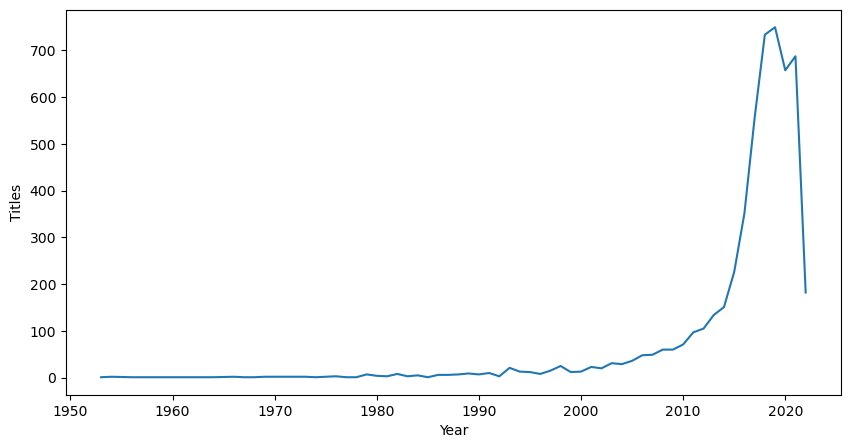

In [32]:
# Create the following plots:
# Line Plot showing number of movies released per year.
# Bar Chart showing number of Movies vs TV Shows.
# Histogram of IMDb scores.

movies_per_year = (
df.groupby("year").size()
)

plt.figure(figsize=(10,5))

plt.plot(
movies_per_year.index,
movies_per_year.values
)

plt.xlabel("Year")
plt.ylabel("Titles")
plt.show() 

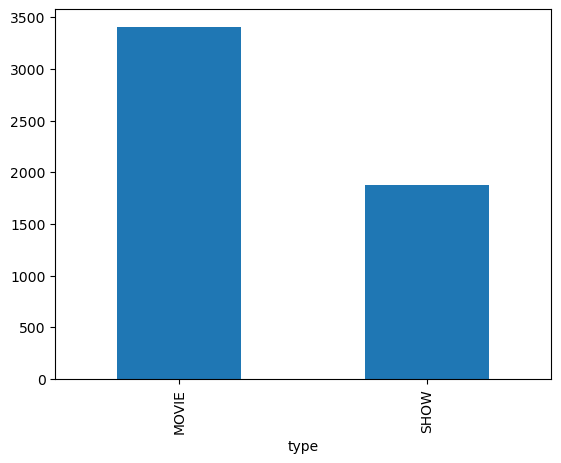

In [33]:
# Bar Chart 
df["type"].value_counts().plot(
kind="bar"
)

plt.show() 

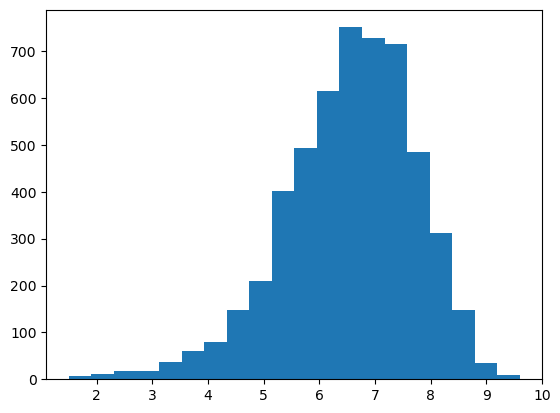

In [34]:
# Histogram 
plt.hist(df["imdb_score"],bins=20)

plt.show() 

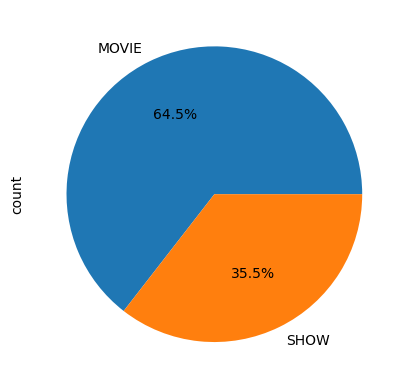

In [35]:
# Create a Pie Chart showing the percentage of Movies and TV Shows.
df["type"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)

plt.show()

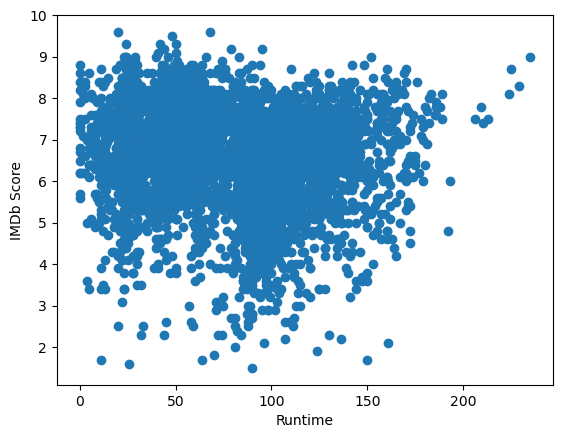

In [36]:
# Create a Scatter Plot showing:
# Runtime vs IMDb Score.

plt.scatter(
df["duration"],
df["imdb_score"]
)

plt.xlabel("Runtime")
plt.ylabel("IMDb Score")

plt.show()

# Part G – Seaborn 

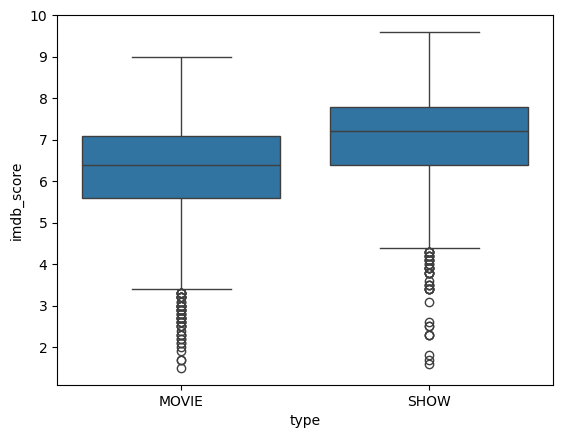

In [37]:
# Create a Box Plot to detect outliers in IMDb scores by content type. 
sns.boxplot(
x="type",
y="imdb_score",
data=df
)

plt.show() 

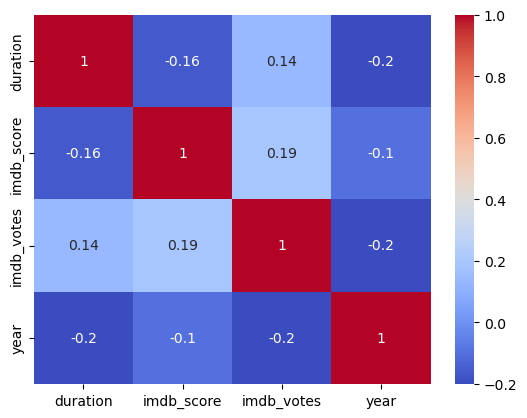

In [38]:
# Create a Heatmap showing the correlation between:
# Runtime
# IMDb Score
# IMDb Votes
# Release Year

corr = df[
[
"duration",
"imdb_score",
"imdb_votes",
"year"
]
].corr()

sns.heatmap(
corr,
annot=True,
cmap="coolwarm"
)

plt.show()

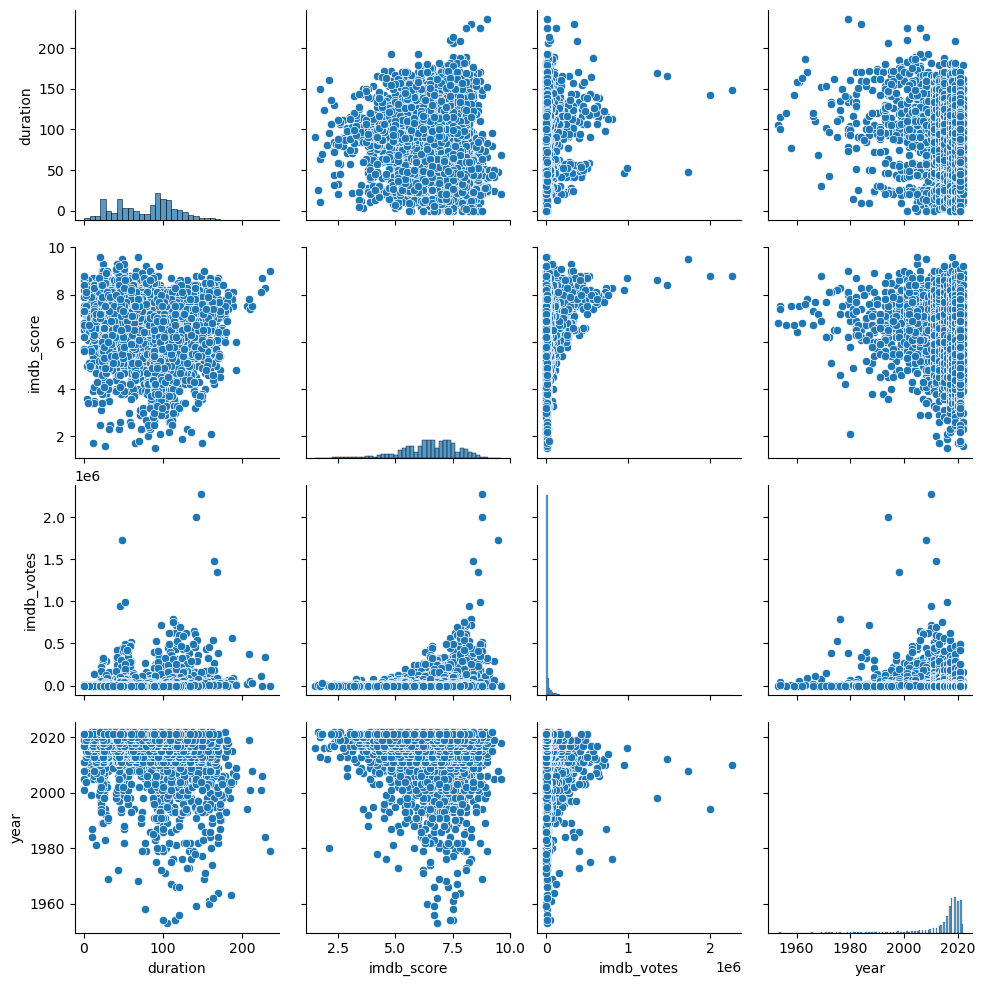

In [39]:
# Create a Pair Plot for the following numerical columns:
# runtime
# imdb_score
# imdb_votes
# release_year

sns.pairplot(
df[
[
"duration",
"imdb_score",
"imdb_votes",
"year"
]
]
)

plt.show()